# Graph creation

In [1]:
import geopandas as gpd
import sys
sys.path.append('..')
import osmnx as ox

## Initialization


The drive graph is generated using the polygon GeoDataFrame and the local CRS.  

Ensure that the local CRS is a Projected CRS (e.g., UTM) rather than a Geographic CRS (e.g., EPSG:4326 - WGS84) to maintain accurate distance calculations.  


In [2]:
geocode = 81993 # Tula region geocode from OSM
polygon = ox.geocode_to_gdf(f'R{geocode}', by_osmid=True)

In [3]:
from transport_frames.graph import get_graph

graph = get_graph(osm_id=geocode) # you can also pass territory GeoDataFrame instead of osm_id

2026-04-04 19:56:22.707 | INFO     | Downloading drive network via Overpass ...
2026-04-04 19:56:23.100 | INFO     | Downloading network via Overpass done!
2026-04-04 19:56:32.566 | WARNING  | Removing 1550 nodes from 262 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (35216 nodes).


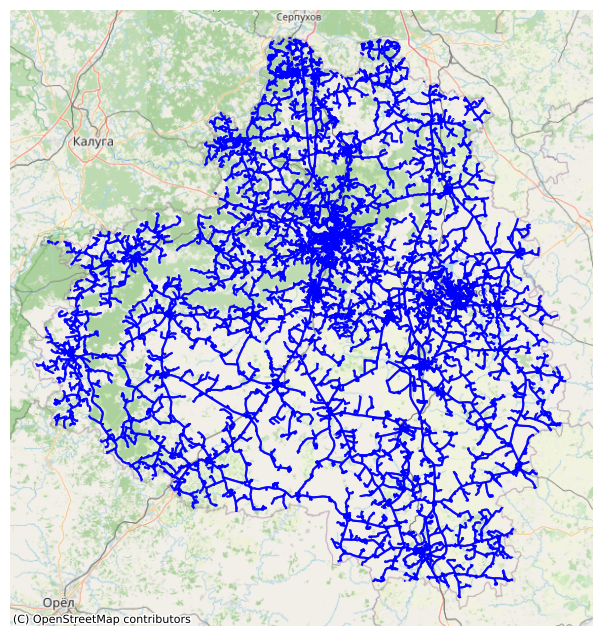

In [4]:
from transport_frames.utils.helper_funcs import plot_graph

plot_graph(graph)

## Frame

Frame consists of federal and regional roads from the graph, adding exit attributes and district centers attributes to the nodes.

In [5]:
regions = gpd.read_file('/Users/sashamorozov/Documents/data_DPO/russia.geojson')
admin_centers = gpd.read_file('/Users/sashamorozov/Documents/data_DPO/tula_region_admin_centers.geojson')

Some cities weren’t assigned to nodes due to remote location: {'Новогуровский', 'Славный'}


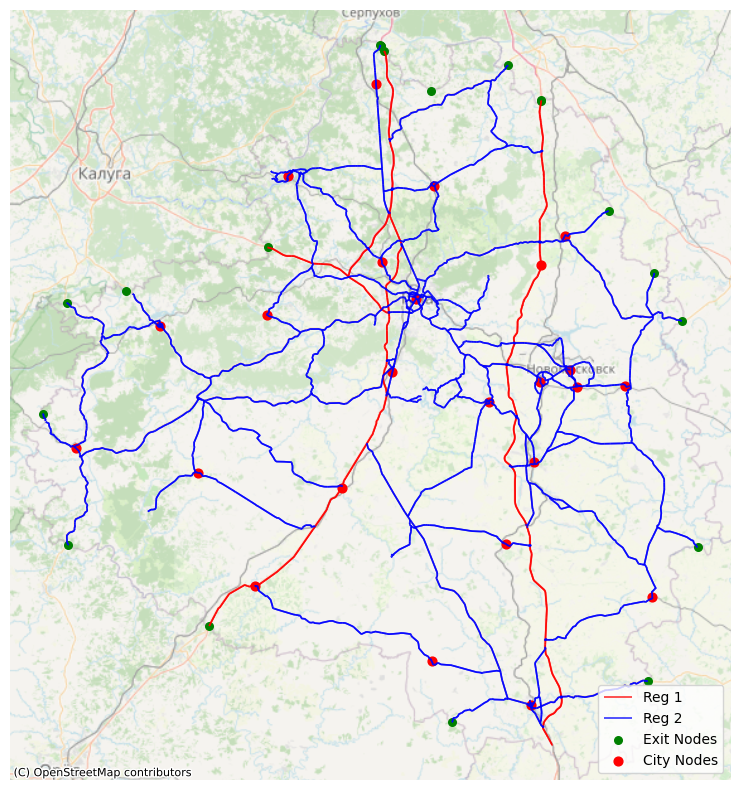

In [6]:
from transport_frames.frame import get_frame, plot_frame

f = get_frame(graph,admin_centers,polygon,regions)

plot_frame(f)

## Weighted frame

Weights are assigned to the edges and nodes based on the expected popularity of the path between pairs of exits.

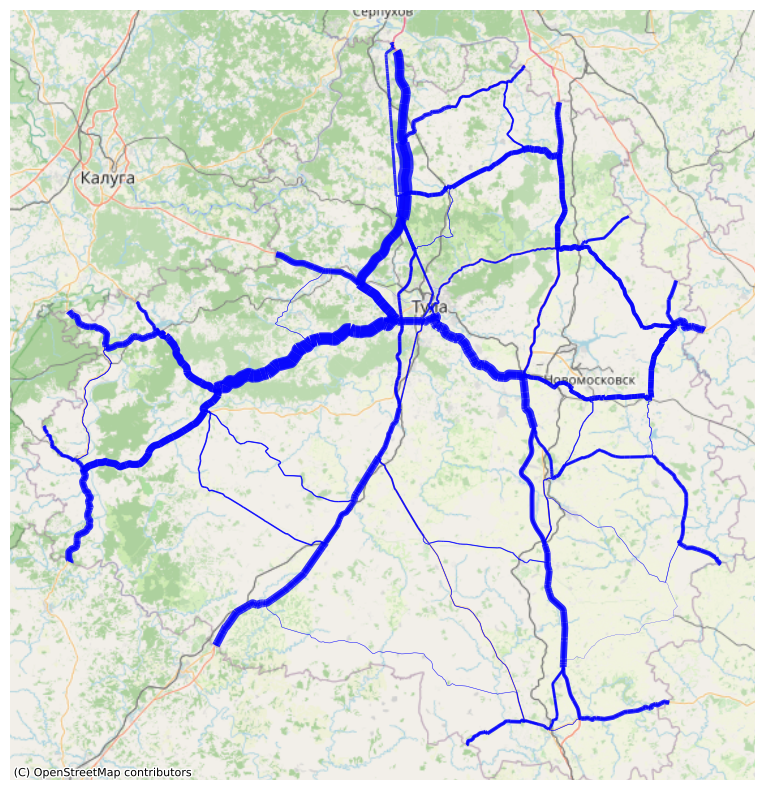

In [7]:
from transport_frames.frame import weigh_roads, plot_weighted_roads

weighted_frame = weigh_roads(f)

plot_weighted_roads(weighted_frame)

## Intermodal graph

Intermodal graph is used for connectivity indicators and routes extraction. It can be obtained using ``iduedu`` library.

In [8]:
from transport_frames.graph import get_intermodal_graph

inter_graph = get_intermodal_graph(osm_id=geocode)

2026-04-04 19:58:10.037 | INFO     | Downloading walk network via Overpass ...
2026-04-04 19:58:10.037 | INFO     | Downloading routes via Overpass with types bus, tram, trolleybus, subway, train ...
2026-04-04 19:58:11.949 | INFO     | Downloading network via Overpass done!
2026-04-04 19:58:11.985 | INFO     | Downloading routes via Overpass with types bus, tram, trolleybus, subway, train done!


Parsing ground PT routes:   0%|          | 0/145 [00:00<?, ?it/s]

2026-04-04 19:58:33.221 | WARNING  | Removing 815 nodes from 261 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (128786 nodes).
2026-04-04 19:58:36.178 | INFO     | Composing intermodal graph...
2026-04-04 19:58:54.498 | WARNING  | Removing 1359 nodes from 1313 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (130539 nodes).


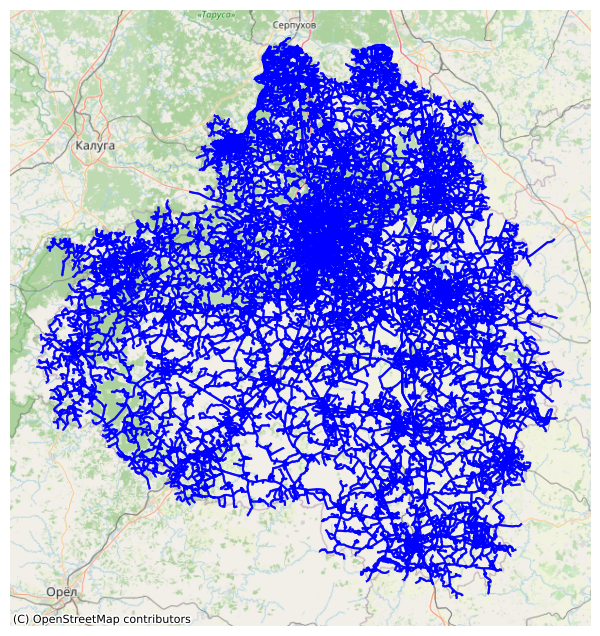

In [9]:
from transport_frames.utils.helper_funcs import plot_graph

plot_graph(inter_graph)